# 02.Distribution Fitting
This notebook shows how to fit probability distributions to data using Numerics.

## What You'll Learn
- Method of Moments (MOM)
- Maximum Likelihood Estimation(MLE)
- L-Momnets
- Comparing Fitted Distributions
- Goodness-of-Fit Diagnostics

## Set Up

In [39]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from System import Array, Double

# Load Numerics DLL (modify path as needed)
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

from Numerics.Distributions import (
    Normal, LogNormal, GammaDistribution, Weibull, GeneralizedExtremeValue, ParameterEstimationMethod
)
from Numerics.Data.Statistics import (
    GoodnessOfFit
)

from helper_functions import convert_to_dotnet_array

print("✓ Setup complete for distribution fitting")

✓ Setup complete for distribution fitting


## Helper Function
The function below is to help plot the histogram of the data with the PDF of the fitted distribution. Graphing a PDF is covered in 01. Distribtions.

In [12]:
def plot_empirical_vs_model(data, dist, title="Empirical vs Fitted Distribution"):
    """Plot histogram of data and PDF of fitted distribution."""
    x = np.linspace(min(data), max(data), 500)
    pdf = [dist.PDF(xi) for xi in x]

    plt.figure(figsize=(10, 6))
    plt.hist(data, bins=20, density=True, alpha=0.5, color="gray", edgecolor="black", label="Empirical")
    plt.plot(x, pdf, "r-", linewidth=2, label="Fitted PDF")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Example Data: Flood Peaks
We'll simulate annual peak flows using a Log-Normal Distribution.

Sample size: 100
Sample mean: 3536.11
Sample std:  2034.79


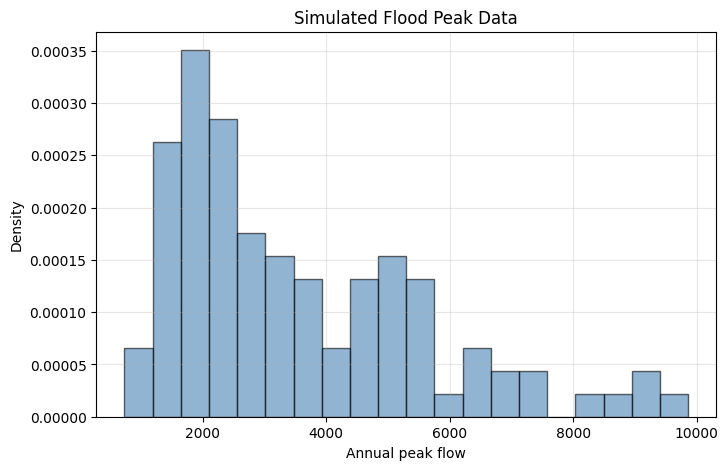

In [ ]:
np.random.seed(123)

data = np.random.lognormal(mean=8, sigma=0.5, size=100)
print(f"Sample size: {len(data)}")
print(f"Sample mean: {np.mean(data):.2f}")
print(f"Sample std:  {np.std(data):.2f}")

plt.figure(figsize=(8, 5))
plt.hist(data, bins=20, density=True, alpha=0.6, color="steelblue", edgecolor="black")
plt.xlabel("Annual Peak Flow")
plt.ylabel("Density")
plt.title("Simulated Flood Peak Data")
plt.grid(True, alpha=0.3)
plt.show()

## Method of Moments (MOM)
Fit a Normal distribution to the data using sample mean and variance.

MOM Normal fit: mu=3536.11, sigma=2034.79


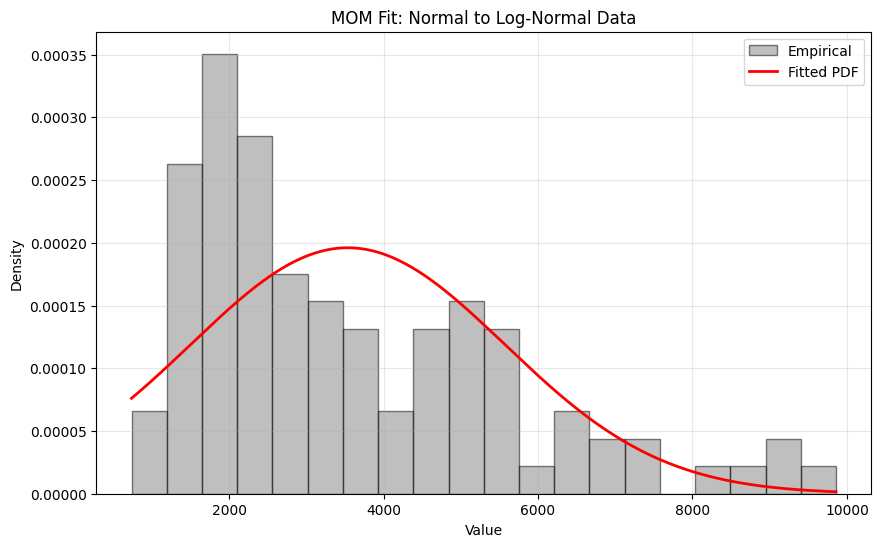

In [7]:
sample_mean = np.mean(data)
sample_var = np.var(data, ddof=1)
sample_std = np.std(data)

# Fit Normal Distribution
normal = Normal(sample_mean, sample_std)
print(f"MOM Normal fit: mu={normal.Mean:.2f}, sigma={normal.StandardDeviation:.2f}")

plot_empirical_vs_model(data, normal, title="MOM Fit: Normal to Log-Normal Data")


## Maximum Likelihood Estimation (MLE)
Continuing with our example we will find the 

MLE Log-Normal fit: mu=3543.16, sigma=0.25


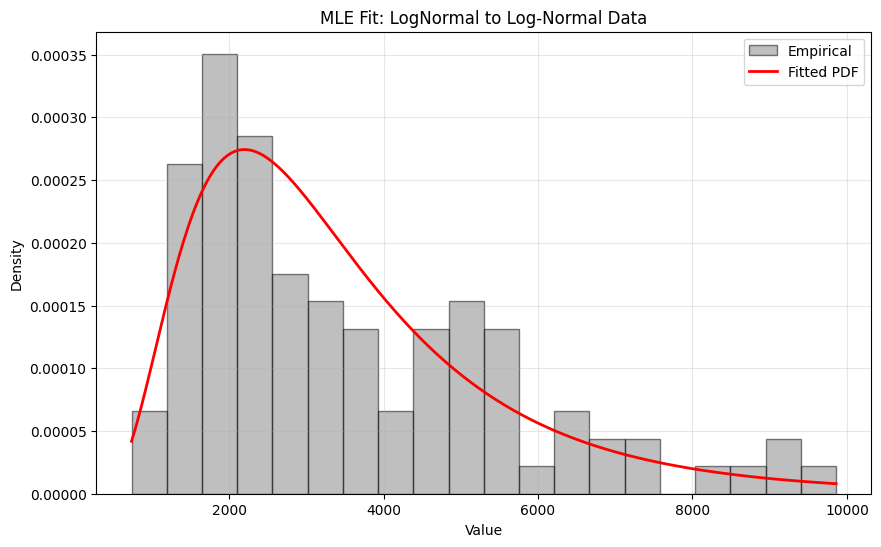

In [21]:
net_data = convert_to_dotnet_array(data)

log_norm = LogNormal()
mle = log_norm.Estimate(net_data, ParameterEstimationMethod.MaximumLikelihood)

print(f"MLE Log-Normal fit: mu={log_norm.Mean:.2f}, sigma={log_norm.Sigma:.2f}")

plot_empirical_vs_model(data, log_norm, title="MLE Fit: LogNormal to Log-Normal Data")

## L-Moments (Regional Frequency)
Demonstrate L_Moment fitting for heavy-tailed distributions. For this section we will fit a Generalized Extreme Value Distributionn to explore.

MLE Log-Normal fit: xi=2528.31, alpha=1408.43, kappa=-0.12, skewness=2.17, kurtosis=13.96


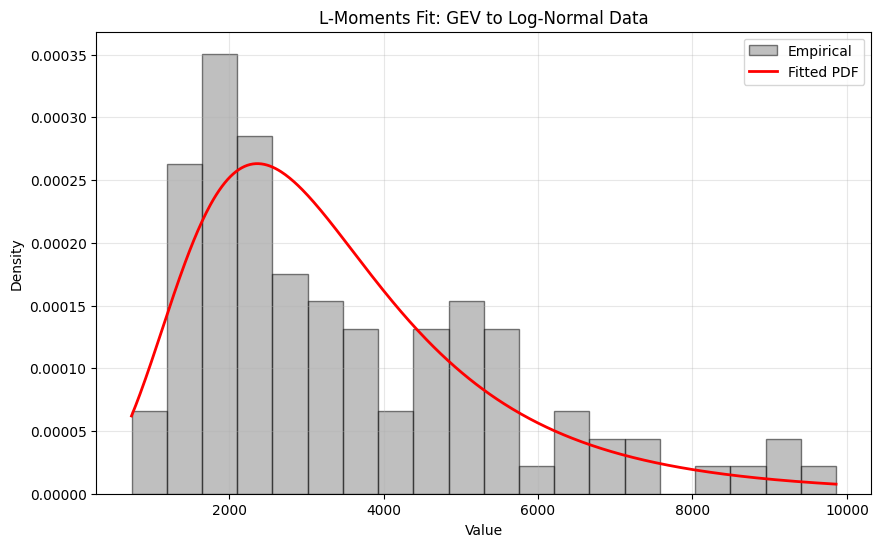

In [30]:
gev = GeneralizedExtremeValue()

l_moments = gev.Estimate(net_data, ParameterEstimationMethod.MethodOfLinearMoments)

print(f"MLE Log-Normal fit: xi={gev.Xi:.2f}, alpha={gev.Alpha:.2f}, kappa={gev.Kappa:.2f}, skewness={gev.Skewness:.2f}, kurtosis={gev.Kurtosis:.2f}")

plot_empirical_vs_model(data, gev, title="L-Moments Fit: GEV to Log-Normal Data")

## Comparing Multiple Fits
We will compares the Normal (MOM), LogNormal (MLE), and GEV (L-Moments) fits from above all together on our example data.


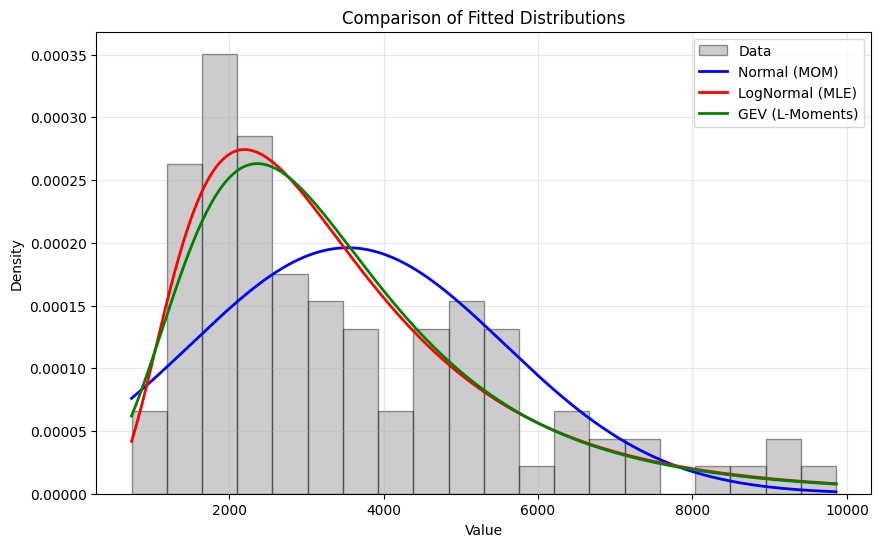

In [31]:
x = np.linspace(min(data), max(data), 500)

plt.figure(figsize=(10, 6))
plt.hist(data, bins=20, density=True, alpha=0.4, color="gray", edgecolor="black", label="Data")

# MOM Normal
normal_pdf = [normal.PDF(xi) for xi in x]
plt.plot(x, normal_pdf, "b-", linewidth=2, label="Normal (MOM)")

# MLE LogNormal 
logn_pdf = [log_norm.PDF(xi) for xi in x]
plt.plot(x, logn_pdf, "r-", linewidth=2, label="LogNormal (MLE)")


# GEV L-Moments 
gev_pdf = [gev.PDF(xi) for xi in x]
plt.plot(x, gev_pdf, "g-", linewidth=2, label="GEV (L-Moments)")

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Comparison of Fitted Distributions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Goodness of Fit Diagnostics
Compute simple metrics, such as log-likelihood and AIC, for each model.

In [51]:
normal_ll = normal.LogLikelihood(net_data)
lognorm_ll = log_norm.LogLikelihood(net_data)
gev_ll = gev.LogLikelihood(net_data)

normal_aic = GoodnessOfFit.AIC(2, normal_ll)
lognorm_aic = GoodnessOfFit.AIC(2, lognorm_ll)
gev_aic = GoodnessOfFit.AIC(3, gev_ll)

normal_bic = GoodnessOfFit.BIC(len(data),2, normal_ll)
lognorm_bic = GoodnessOfFit.BIC(len(data),2, lognorm_ll)
gev_bic = GoodnessOfFit.BIC(len(data),3, gev_ll)

normal_rmse = GoodnessOfFit.RMSE(net_data, normal)
lognorm_rmse = GoodnessOfFit.RMSE(net_data, log_norm)
gev_rmse = GoodnessOfFit.RMSE(net_data, gev)


results = pd.DataFrame({
    "Distribution": ["Normal (MOM)", "LogNormal (MLE)", "GEV (L-Moments)"],
    "Log-Likelihood": [normal_ll, lognorm_ll, gev_ll],  
    "AIC": [normal_aic, lognorm_aic, gev_aic],
    "BIC": [normal_bic, lognorm_bic, gev_bic],
    "RMSE": [normal_rmse, lognorm_rmse, gev_rmse]
})
print(results)

      Distribution  Log-Likelihood          AIC          BIC        RMSE
0     Normal (MOM)     -903.708398  1811.416795  1816.627136  611.891506
1  LogNormal (MLE)     -886.000523  1776.001045  1781.211386  238.896657
2  GEV (L-Moments)     -887.875853  1781.751707  1789.567217  255.761690



## Plotting Fitted vs Empericial CDF

## Bootstrap Confidence Intervals on Parameters

## Plotting Positions